<a href="https://colab.research.google.com/github/Rushikeshaya/Generative-AI/blob/main/Text_Classification_using_Embedding_Layer_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Imports & Setup

In [1]:
# CELL 1: Imports & Environment Setup
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


##Dataset Preparation

In [2]:
# CELL 2: Dataset Creation & Train-Test Split
texts = [
    "The product is amazing and works perfectly!",
    "Extremely disappointed with the poor quality.",
    "Shipping was fast, but the package was damaged.",
    "I love using this app every single day.",
    "Terrible customer support and useless item.",
    "The item arrived on time and neutral performance.",
    "Great experience overall, highly recommended!",
    "Worst purchase I have ever made on this platform.",
    "Average quality, nothing special about it.",
    "Outstanding features and brilliant build quality.",
    "Faulty hardware, stopped working after two days.",
    "It is okay, neither bad nor exceptional."
]

# here i have given some valuse such as 0 to positive 1 to negative and 2 to neutral
labels = [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2]

# here i have split above text into train and test which will train it and after that test data will evaluate its performance
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 9 | Testing samples: 3


##Text Vectorization

In [3]:
# CELL 3: Text Vectorization & Vocabulary Fitting
VOCAB_SIZE = 1000
MAX_LEN = 20
EMBEDDING_DIM = 64
NUM_CLASSES = 3

# Define text vectorizer
vectorize_layer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# Learn vocabulary from training set
vectorize_layer.adapt(X_train)

# Transform raw text into padded integer arrays
X_train_seq = vectorize_layer(np.array(X_train))
X_test_seq = vectorize_layer(np.array(X_test))

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Sample Vocabulary:", vectorize_layer.get_vocabulary()[:10])

Sample Vocabulary: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('was'), np.str_('quality'), np.str_('item'), np.str_('is'), np.str_('works'), np.str_('working')]


##Model Architecture

In [4]:
# CELL 4: Building the Embedding + LSTM Model
model = models.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="Input_Tokens"),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, name="Embedding_Layer"),
    layers.SpatialDropout1D(0.2, name="Spatial_Dropout"),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2, name="LSTM_Layer"),
    layers.Dense(32, activation='relu', name="Dense_Hidden"),
    layers.Dense(NUM_CLASSES, activation='softmax', name="Output_Classification")
], name="LSTM_Text_Classifier")

model.summary()

Model: "LSTM_Text_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding_Layer (Embedding)     │ (None, 20, 64)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Spatial_Dropout                 │ (None, 20, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Layer (LSTM)               │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classification (Dense)   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,203 (387.51 KB)

 Trainable params: 99,203 (387.51 KB)

 Non-trainable params: 0 (0.00 B)

##Model Compilation & Training

In [5]:
# CELL 5: Model Compilation & Training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_seq,
    y_train,
    epochs=15,
    batch_size=2,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.2857 - loss: 1.1082 - val_accuracy: 0.5000 - val_loss: 1.1018
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1429 - loss: 1.1003 - val_accuracy: 0.5000 - val_loss: 1.1140
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4286 - loss: 1.1110 - val_accuracy: 0.0000e+00 - val_loss: 1.1231
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2857 - loss: 1.1017 - val_accuracy: 0.0000e+00 - val_loss: 1.1222
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4286 - loss: 1.0926 - val_accuracy: 0.0000e+00 - val_loss: 1.1259
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4286 - loss: 1.1029 - val_accuracy: 0.0000e+00 - val_loss: 1.1245
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4286 - loss: 1.0939 - val_accuracy: 0.0000e+00 - val_loss: 1.1289
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4286 - loss: 1.0887 - val_accuracy: 0.000

##Model Evaluation

In [6]:
# CELL 6: Model Evaluation & Performance Metrics
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = ['Positive', 'Negative', 'Neutral']

print("\n" + "="*40)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("="*40)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step

Overall Accuracy: 0.3333

Confusion Matrix:
[[0 1 0]
 [0 1 0]
 [0 1 0]]

Detailed Classification Report:
              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00         1
    Negative       0.33      1.00      0.50         1
     Neutral       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



##Inference on New Data

In [7]:
# CELL 7: Inference Function for Unseen Text
new_sentences = [
    "This product exceeded all my expectations!",
    "Broken upon arrival, very dissatisfied."
]

# Convert text to integer sequences using the fitted layer
new_sequences = vectorize_layer(np.array(new_sentences))
predictions = model.predict(new_sequences)

for text, pred in zip(new_sentences, predictions):
    class_idx = np.argmax(pred)
    confidence = pred[class_idx]
    print(f"\nText: \"{text}\"\nPrediction: {target_names[class_idx]} ({confidence*100:.2f}% confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step

Text: "This product exceeded all my expectations!"
Prediction: Negative (43.27% confidence)

Text: "Broken upon arrival, very dissatisfied."
Prediction: Negative (43.56% confidence)


##Visualizing Training & Validation Performance

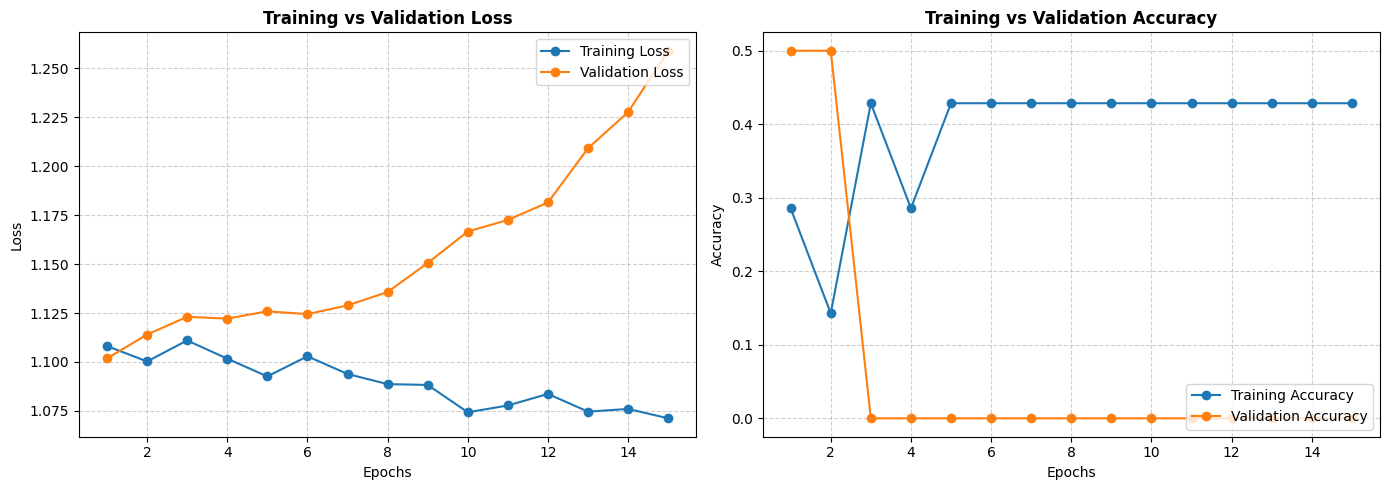

In [8]:
# CELL 8: Plotting Loss and Accuracy Curves
import matplotlib.pyplot as plt

# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Conclusion from Training and Validation Performance

The generated plots illustrate the model's performance over 15 epochs. Here are the key observations:

*   **Training Loss vs. Validation Loss:** The training loss decreases steadily, which is expected as the model learns from the training data. However, the validation loss remains high and even shows a general increasing trend after the initial epochs. This divergence indicates that the model is likely **overfitting** the training data; it performs well on data it has seen but generalizes poorly to unseen validation data.

*   **Training Accuracy vs. Validation Accuracy:** Similarly, the training accuracy shows some improvement (though fluctuating), while the validation accuracy starts low and either stays stagnant at 0% (after the first epoch) or drops. This further confirms the overfitting issue.

**Overall:** The model, in its current state, is not generalizing effectively to new data. This could be due to several factors, including a very small dataset, an overly complex model for the given data, or insufficient regularization. Further steps should involve increasing the dataset size, simplifying the model, or adjusting hyperparameters for better generalization.

### Graph Conclusion:

The plots clearly indicate **overfitting**. Training loss decreases while validation loss increases, and validation accuracy remains low. The model struggles to generalize to unseen data, suggesting issues with the small dataset, model complexity, or lack of regularization.